# A3.1 Tutorial PCA
**Universidad de Monterrey**  
Escuela de Ingeniería y Tecnologías  
Inteligencia Artificial I  

**Estudiante:** Anna Carolina de Azevedo Leite  
**Docente:** Antonio Martínez Torteya  
**Fecha:** 13 de Abril de 2026  

## Introducción

El Análisis de Componentes Principales (PCA, por sus siglas en inglés) es una técnica de reducción de dimensionalidad ampliamente utilizada en el área de inteligencia artificial y aprendizaje automático. Su objetivo principal es transformar un conjunto de variables originales en un nuevo conjunto de variables no correlacionadas llamadas componentes principales, conservando la mayor cantidad posible de información (varianza) de los datos.

En esta actividad, se utilizará PCA como una etapa de preprocesamiento para analizar su impacto en tareas de clasificación. Además, se estudiará la proporción de varianza explicada por cada componente y se interpretarán las cargas (loadings) para entender qué variables originales tienen mayor influencia en los nuevos componentes generados.

El dataset utilizado será el *Breast Cancer Wisconsin*, el cual contiene características extraídas de imágenes de tumores, permitiendo clasificar si estos son benignos o malignos.

**El desarrollo de esta actividad seguirá los siguientes pasos:**

- Exploración inicial del dataset (estructura, variables y clases)
- Visualización de los datos (análisis univariable y bivariable)
- Preprocesamiento de los datos (división en entrenamiento y prueba, estandarización)
- Entrenamiento de un modelo de clasificación sin PCA (baseline)
- Aplicación de PCA y análisis de la varianza explicada
- Entrenamiento del modelo utilizando los datos transformados con PCA
- Comparación de resultados e interpretación de los componentes principales

De esta manera, se busca comprender no solo cómo aplicar PCA, sino también cómo interpretar sus resultados y evaluar su utilidad dentro de un flujo de trabajo de machine learning.

---

## 1. Exploración Inicial del Dataset
En esta sección se realiza una exploración inicial del dataset *Breast Cancer Wisconsin*, con el objetivo de comprender su estructura, características y calidad de los datos antes de aplicar cualquier técnica de modelado o reducción de dimensionalidad.

Se analizarán aspectos como:
- Las primeras filas del dataset
- Dimensiones (número de filas y columnas)
- Tipos de datos
- Clases disponibles
- Presencia de valores nulos

In [27]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

# Cargar el dataset
cancer = load_breast_cancer()

# Crear un DataFrame para los datos y otro para los labelsdf
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

print("Características del dataset:")
display(df.head())

Características del dataset:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Se carga el dataset y se convierte en un DataFrame para facilitar su manipulación y análisis.

La función `head()` muestra las primeras filas del dataset, permitiendo observar cómo están organizados los datos. Cada fila representa un tumor y cada columna corresponde a una característica numérica.

La columna **target** indica la clasificación:
- 0 → maligno
- 1 → benigno

Esto permite entender la estructura general del dataset antes de continuar con el análisis.

In [28]:
print("Tamaño del dataset (filas, columnas)", df.shape)
display(df.info())
print("\nClasses (target_names):", cancer.target_names)

Tamaño del dataset (filas, columnas) (569, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-

None


Classes (target_names): ['malignant' 'benign']


El tamaño del dataset indica que contiene 569 muestras y 31 columnas (30 características + 1 variable objetivo).

El método `info()` muestra que todas las variables son de tipo numérico (float64 o int64), lo cual es adecuado para aplicar técnicas como PCA.

Además, se observan las clases disponibles:
- **malignant** (maligno)
- **benign** (benigno)

Esto confirma que el problema es de clasificación binaria.

In [29]:
print("Revisar si hay valores nulos (huecos):")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No hay valores nulos en el dataset.")

Revisar si hay valores nulos (huecos):
Series([], dtype: int64)
No hay valores nulos en el dataset.


Se verifica si existen valores nulos en el dataset, lo cual es importante ya que estos pueden afectar el rendimiento de los modelos.

El resultado muestra que no hay valores faltantes, por lo tanto, no es necesario realizar procesos adicionales de limpieza de datos en este aspecto.

Esto facilita el flujo de trabajo, ya que se puede continuar directamente con el preprocesamiento y modelado.

---

## 2. Visualización de los Datos

Una vez comprendida la estructura del dataset, es importante realizar un análisis visual para identificar patrones, distribuciones y posibles relaciones entre variables.

En esta sección se realizan:
- Visualizaciones univariables (una sola variable)
- Visualizaciones bivariable (relación entre dos variables)

Esto permite observar diferencias entre clases (benigno vs maligno) y entender mejor el comportamiento de los datos antes del modelado.

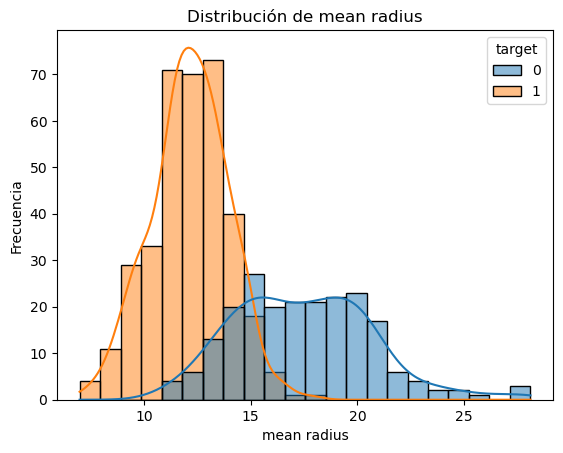

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar una variable para analizar
variable = 'mean radius'

# Histograma con separación por clase
plt.figure()
sns.histplot(data=df, x=variable, hue="target", kde=True)

plt.title(f"Distribución de {variable}")
plt.xlabel(variable)
plt.ylabel("Frecuencia")

plt.show()

### Interpretación (Univariable)

En esta gráfica se observa la distribución de una sola variable (*mean radius*) separada por clase.

Se puede notar cómo los valores de tumores malignos y benignos tienden a agruparse en diferentes rangos, lo cual indica que esta variable tiene capacidad discriminativa.

Este tipo de análisis permite identificar qué variables pueden ser útiles para la clasificación.

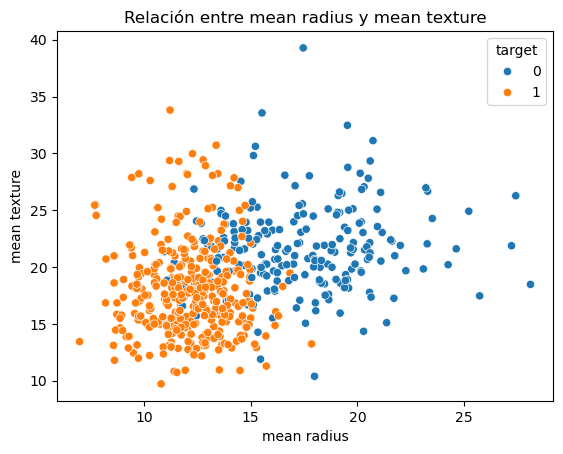

In [31]:
# Gráfica de dispersión entre dos variables
plt.figure()

sns.scatterplot(
    data=df,
    x='mean radius',
    y='mean texture',
    hue='target'
)

plt.title("Relación entre mean radius y mean texture")
plt.xlabel("mean radius")
plt.ylabel("mean texture")

plt.show()

### Interpretación (Bivariable)

La gráfica de dispersión permite analizar la relación entre dos variables al mismo tiempo.

Se observa que existe cierta separación entre las clases (benigno y maligno), lo cual sugiere que la combinación de estas variables puede ser útil para un modelo de clasificación.

Este tipo de visualización ayuda a entender la estructura del problema en un espacio de dos dimensiones.

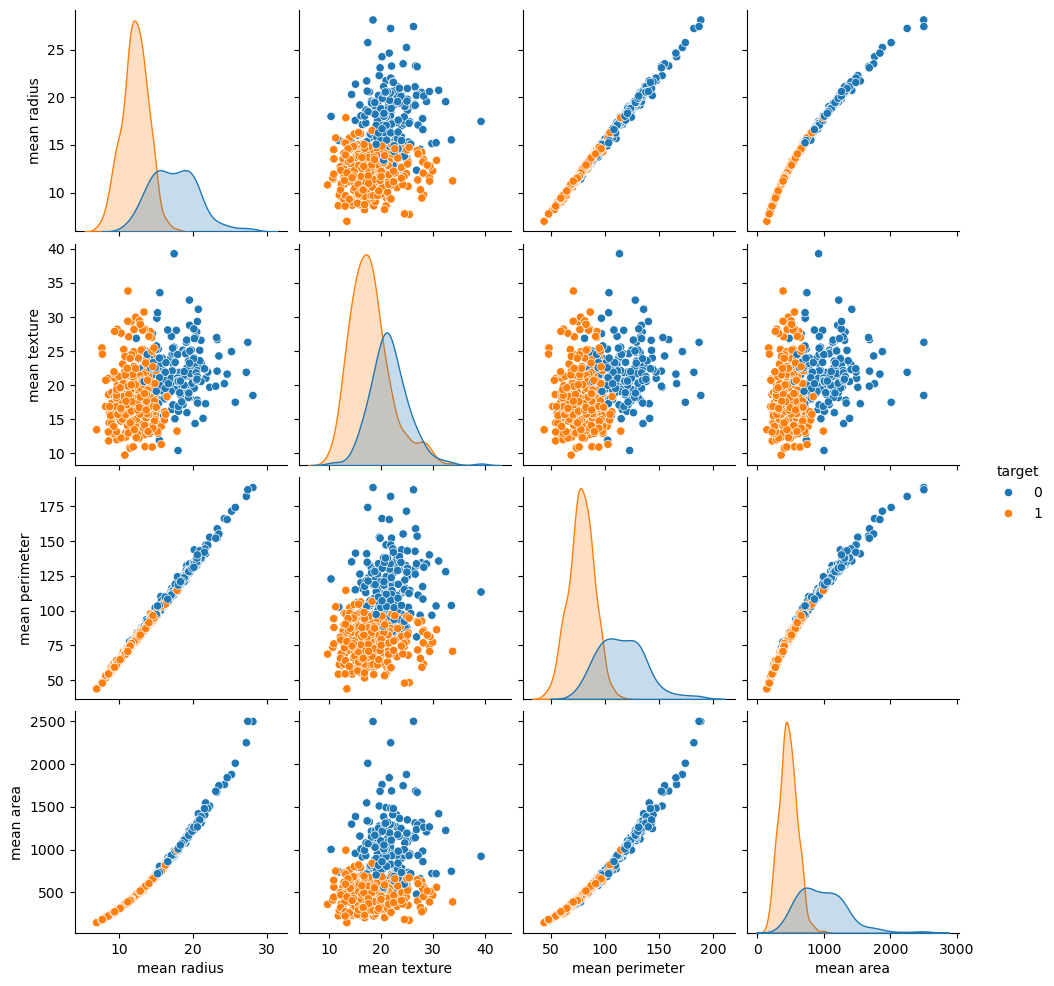

In [32]:
# Pairplot de algunas variables (subset para no sobrecargar)
subset_cols = ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'target']

sns.pairplot(df[subset_cols], hue="target")

plt.show()

### Interpretación (Relaciones múltiples)

El pairplot permite visualizar múltiples combinaciones de variables al mismo tiempo.

Se pueden observar patrones de separación entre clases en diferentes combinaciones, lo que indica que el dataset contiene información relevante para la clasificación.

Además, este tipo de visualización ayuda a identificar correlaciones entre variables, lo cual es importante antes de aplicar PCA.

---

## 3. Preprocesamiento de los Datos

Antes de entrenar cualquier modelo o aplicar PCA, es necesario preparar los datos adecuadamente.

En esta sección se realizarán dos pasos fundamentales:

- División del dataset en conjunto de entrenamiento y prueba
- Estandarización de los datos

La estandarización es especialmente importante para PCA, ya que esta técnica es sensible a la escala de las variables.

In [33]:
from sklearn.model_selection import train_test_split

# Separar variables de entrada (X) y variable objetivo (y)
X = df.drop(columns=["target"])
y = df["target"]

# Dividir en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3,
    random_state=42
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (398, 30)
Shape X_test: (171, 30)


Se divide el dataset en dos conjuntos:

- **Entrenamiento (70%)**: utilizado para entrenar el modelo
- **Prueba (30%)**: utilizado para evaluar el desempeño del modelo

Esto permite medir qué tan bien generaliza el modelo a datos no vistos.

El uso de `random_state=42` garantiza que la división sea reproducible.

In [34]:
from sklearn.preprocessing import StandardScaler

# Crear el escalador
scaler = StandardScaler()

# Ajustar SOLO con entrenamiento y transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Se aplica una estandarización a los datos, transformando cada variable para que tenga:

- Media = 0
- Desviación estándar = 1

Esto es importante porque:

- Evita que variables con mayor escala dominen el modelo
- Es un requisito clave para PCA, ya que este se basa en la varianza de los datos

El escalador se ajusta únicamente con los datos de entrenamiento (`fit_transform`) y luego se aplica a los datos de prueba (`transform`), evitando fuga de información (*data leakage*).

In [35]:
import numpy as np

print("Media (aprox 0):", np.mean(X_train_scaled, axis=0)[:5])
print("Std (aprox 1):", np.std(X_train_scaled, axis=0)[:5])

Media (aprox 0): [-1.20869255e-15 -3.93292322e-15 -3.50361839e-15  2.23160407e-16
 -2.97863353e-15]
Std (aprox 1): [1. 1. 1. 1. 1.]


Se verifica que los datos han sido correctamente estandarizados.

Los valores muestran que:
- La media es cercana a 0
- La desviación estándar es cercana a 1

Esto confirma que el preprocesamiento se realizó correctamente.

---

## 4. Modelo de Clasificación (Sin PCA)

Antes de aplicar PCA, se entrena un modelo de clasificación utilizando los datos originales (ya estandarizados). 

Esto sirve como referencia (*baseline*) para posteriormente comparar si la aplicación de PCA mejora o no el desempeño del modelo.

Se utilizará un modelo de regresión logística, ya que es un método ampliamente utilizado para problemas de clasificación binaria.

In [36]:
from sklearn.linear_model import LogisticRegression

# Crear el modelo
model = LogisticRegression(max_iter=1000)

# Entrenar el modelo con datos estandarizados
model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Se entrena un modelo de regresión logística utilizando los datos de entrenamiento previamente estandarizados.

El parámetro `max_iter=1000` se utiliza para asegurar la convergencia del modelo durante el entrenamiento.

In [37]:
# Realizar predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

Se generan predicciones utilizando el conjunto de prueba.

- `y_pred`: clases predichas
- `y_prob`: probabilidades asociadas a la clase positiva (benigno)

Estas probabilidades serán útiles para calcular métricas como AUC.

In [38]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# Métricas principales
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("AUC:", auc)

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9824561403508771
F1 Score: 0.986046511627907
AUC: 0.9979423868312757

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98        63
           1       0.99      0.98      0.99       108

    accuracy                           0.98       171
   macro avg       0.98      0.98      0.98       171
weighted avg       0.98      0.98      0.98       171



Se evalúa el desempeño del modelo utilizando varias métricas:

- **Accuracy**: proporción de predicciones correctas
- **F1 Score**: balance entre precisión y recall (especialmente útil en clasificación)
- **AUC**: capacidad del modelo para separar las clases

El reporte de clasificación muestra métricas detalladas por clase.

Estos resultados servirán como punto de comparación para evaluar el impacto de PCA en el modelo.

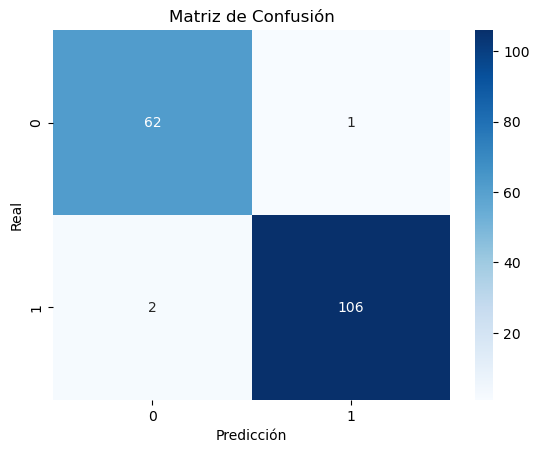

In [39]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")

plt.show()

La matriz de confusión permite visualizar:

- Verdaderos positivos
- Verdaderos negativos
- Errores del modelo

Esto ayuda a entender en qué casos el modelo está fallando y qué tipo de errores son más frecuentes.

---

## 4. Análisis de Componentes Principales (PCA)

El Análisis de Componentes Principales (PCA) es una técnica de reducción de dimensionalidad que transforma las variables originales en un nuevo conjunto de variables llamadas componentes principales.

Estas nuevas variables:
- No están correlacionadas entre sí
- Están ordenadas según la cantidad de varianza que explican

El objetivo es reducir la cantidad de variables manteniendo la mayor cantidad de información posible.

En esta sección se aplicará PCA sobre los datos estandarizados y se analizará la varianza explicada para determinar cuántos componentes conservar.

In [40]:
from sklearn.decomposition import PCA

# Crear PCA sin limitar número de componentes
pca = PCA()

# Ajustar con datos de entrenamiento
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

Se aplica PCA sobre los datos estandarizados.

Inicialmente no se limita el número de componentes, ya que el objetivo es analizar cuánta varianza explica cada uno y así determinar cuántos son necesarios.

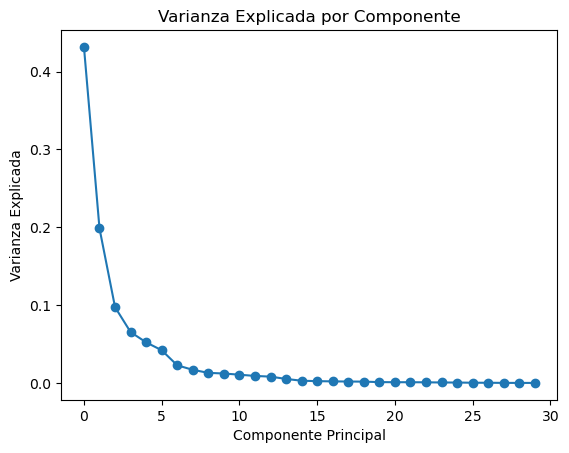

In [41]:
import matplotlib.pyplot as plt

# Varianza explicada individual
explained_variance = pca.explained_variance_ratio_

plt.figure()
plt.plot(explained_variance, marker='o')

plt.title("Varianza Explicada por Componente")
plt.xlabel("Componente Principal")
plt.ylabel("Varianza Explicada")

plt.show()

El gráfico muestra cuánta varianza explica cada componente principal.

Se busca identificar el "codo" (*elbow*), es decir, el punto donde agregar más componentes deja de aportar una mejora significativa.

Esto ayuda a decidir cuántos componentes conservar.

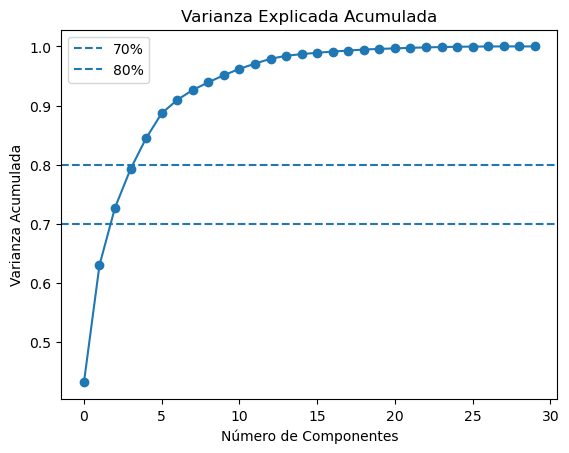

In [42]:
import numpy as np

# Varianza acumulada
cumulative_variance = np.cumsum(explained_variance)

plt.figure()
plt.plot(cumulative_variance, marker='o')

plt.title("Varianza Explicada Acumulada")
plt.xlabel("Número de Componentes")
plt.ylabel("Varianza Acumulada")

plt.axhline(y=0.7, linestyle='--', label="70%")
plt.axhline(y=0.8, linestyle='--', label="80%")

plt.legend()
plt.show()

La varianza acumulada muestra cuánta información total se conserva al usar un cierto número de componentes.

Por ejemplo:
- 70% → modelo más compacto
- 80% → mejor representación de los datos

Este criterio se utiliza para seleccionar el número óptimo de componentes principales.

In [43]:
# Elegir número de componentes (ejemplo: 5)
n_components = 5

pca = PCA(n_components=n_components)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Shape original:", X_train_scaled.shape)
print("Shape con PCA:", X_train_pca.shape)

Shape original: (398, 30)
Shape con PCA: (398, 5)


Se selecciona un número reducido de componentes principales en función del análisis de varianza.

Esto permite:
- Reducir la dimensionalidad del dataset
- Mantener la mayor cantidad posible de información

Se puede observar cómo disminuye el número de variables en comparación con el dataset original.

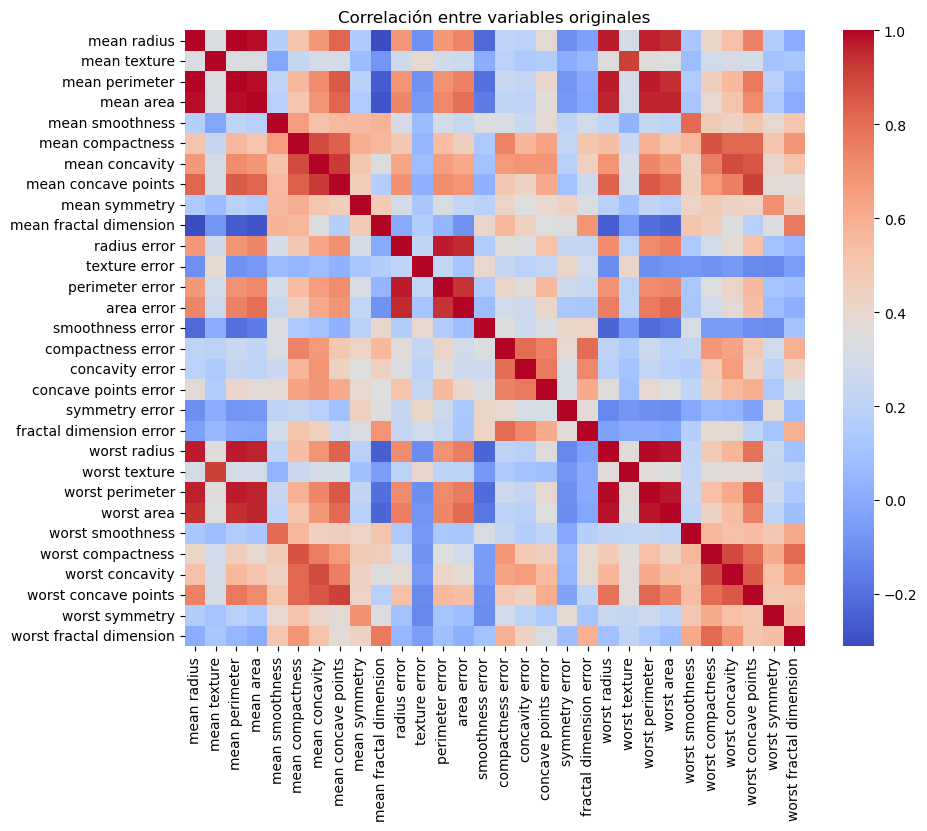

In [44]:
import seaborn as sns

# Correlación de variables originales
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=["target"]).corr(), cmap="coolwarm")

plt.title("Correlación entre variables originales")
plt.show()

El heatmap muestra la correlación entre las variables originales.

Se observa que muchas variables están altamente correlacionadas, lo cual justifica el uso de PCA, ya que esta técnica busca eliminar redundancia y representar los datos en un espacio de menor dimensión.

---

## 6. Modelo de Clasificación utilizando PCA

Una vez aplicada la reducción de dimensionalidad con PCA, se entrena nuevamente el modelo de clasificación.

El objetivo es evaluar si el uso de PCA mejora el desempeño del modelo o permite obtener resultados similares utilizando menos variables.

In [45]:
# Crear nuevamente el modelo
model_pca = LogisticRegression(max_iter=1000)

# Entrenar con los datos transformados por PCA
model_pca.fit(X_train_pca, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Se entrena el mismo modelo de regresión logística, pero ahora utilizando los datos transformados mediante PCA.

Esto permite comparar directamente el impacto de la reducción de dimensionalidad en el desempeño del modelo.

In [46]:
# Predicciones con PCA
y_pred_pca = model_pca.predict(X_test_pca)
y_prob_pca = model_pca.predict_proba(X_test_pca)[:, 1]

Se generan predicciones utilizando el modelo entrenado con PCA.

Al igual que en el modelo anterior:
- `y_pred_pca` contiene las clases predichas
- `y_prob_pca` contiene las probabilidades para calcular AUC

In [47]:
# Métricas con PCA
accuracy_pca = accuracy_score(y_test, y_pred_pca)
f1_pca = f1_score(y_test, y_pred_pca)
auc_pca = roc_auc_score(y_test, y_prob_pca)

print("Accuracy (PCA):", accuracy_pca)
print("F1 Score (PCA):", f1_pca)
print("AUC (PCA):", auc_pca)

print("\nReporte de Clasificación (PCA):")
print(classification_report(y_test, y_pred_pca))

Accuracy (PCA): 0.9883040935672515
F1 Score (PCA): 0.9907407407407407
AUC (PCA): 0.9986772486772487

Reporte de Clasificación (PCA):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        63
           1       0.99      0.99      0.99       108

    accuracy                           0.99       171
   macro avg       0.99      0.99      0.99       171
weighted avg       0.99      0.99      0.99       171



Se evalúa el modelo utilizando PCA con las mismas métricas que el modelo original.

Esto permite realizar una comparación directa entre ambos enfoques.

In [48]:
print("=== Comparación de Modelos ===\n")

print("SIN PCA")
print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("AUC:", auc)

print("\nCON PCA")
print("Accuracy:", accuracy_pca)
print("F1 Score:", f1_pca)
print("AUC:", auc_pca)

=== Comparación de Modelos ===

SIN PCA
Accuracy: 0.9824561403508771
F1 Score: 0.986046511627907
AUC: 0.9979423868312757

CON PCA
Accuracy: 0.9883040935672515
F1 Score: 0.9907407407407407
AUC: 0.9986772486772487


Se comparan los resultados obtenidos con y sin PCA.

Esto permite analizar:

- Si el desempeño mejora, empeora o se mantiene similar
- Si es posible reducir la dimensionalidad sin perder información relevante

En muchos casos, PCA permite obtener resultados comparables utilizando menos variables, lo cual simplifica el modelo.

In [49]:
# Mostrar las cargas de los componentes principales
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns
)

loadings.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,0.216927,0.106841,0.226026,0.219594,0.141974,0.238731,0.260357,0.263648,0.148065,0.058694,...,0.226308,0.107381,0.236046,0.223943,0.125357,0.207062,0.232988,0.252293,0.122468,0.125055
1,-0.237700,-0.044474,-0.220103,-0.233867,0.179887,0.158836,0.059628,-0.037974,0.179719,0.360696,...,-0.223346,-0.032596,-0.203184,-0.221855,0.170141,0.153409,0.098852,-0.002558,0.121710,0.284607
2,-0.009763,0.063888,-0.010380,0.026276,-0.126396,-0.072800,0.004566,-0.038050,-0.046923,-0.020246,...,-0.054419,-0.050009,-0.054778,-0.019510,-0.280698,-0.230659,-0.169829,-0.182134,-0.285881,-0.221250
3,-0.041359,0.605147,-0.043286,-0.058593,-0.129320,-0.041936,-0.039805,-0.063297,-0.017263,-0.074808,...,-0.012589,0.640635,-0.010395,-0.029068,-0.007324,0.076855,0.041477,0.003727,0.066975,0.022767
4,-0.046919,0.003762,-0.047118,-0.012485,0.395103,-0.013418,-0.091664,0.047019,0.267022,0.063646,...,-0.009945,0.038106,-0.025420,0.016860,0.323525,-0.137980,-0.200747,-0.046523,0.202370,-0.085451


## Interpretación de Componentes Principales

Las cargas (*loadings*) indican cuánto contribuye cada variable original a cada componente principal.

Valores altos (positivos o negativos) indican mayor influencia.

Esto permite interpretar qué variables son más importantes en la nueva representación generada por PCA.

---

## Conclusión

En esta actividad se aplicó el Análisis de Componentes Principales (PCA) como técnica de reducción de dimensionalidad dentro de un flujo de trabajo de machine learning.

Se inició con una exploración del dataset, seguida de su preprocesamiento mediante estandarización. Posteriormente, se entrenó un modelo de clasificación base utilizando regresión logística.

Luego, se aplicó PCA y se analizó la varianza explicada para seleccionar un número adecuado de componentes principales. Con estos datos transformados, se entrenó nuevamente el modelo y se compararon los resultados.

Los resultados muestran que es posible reducir la cantidad de variables manteniendo un desempeño similar en el modelo, lo cual demuestra la utilidad de PCA para simplificar el dataset sin perder información significativa.

Además, el análisis de las cargas permitió interpretar qué variables tienen mayor impacto en los componentes principales, facilitando una mejor comprensión del problema.

En conclusión, PCA es una herramienta poderosa tanto para visualización como para preprocesamiento en modelos de clasificación.